12 adds to 11 by importing everything, making this file simpler

restart kernel is autoreload errors

### Attempting Fixed Horizon MPC

https://arxiv.org/html/2505.01617v1

I have been doing shrinking horizon control, where the start position of each trajectory optimization is the expected pose of the robot at some transition time t based on the previous trajectory optimization.

The paper above says that Fixed Horizon MPC may work better, which I will try below. I need to find a way to objectively measure which one is better.

One large benefit of fixed horizon MPC is that i can use the trajectory from the previous MPC loop as the initial guess for the next (since each trajectory will be much more similar than in shrinking horizon, where the start position changes each time)

### Preventing "stabby" swings

Additionally, the swings of previous versions have been stabby, AKA to achieve the velocity constraint during the ball hit time, it moves abruptly and short right at the ball hit time.

I think it would be an improvement if the forward swing was longer, so the ball hit time didn't need to be timed exactly, and also the joint acceleration wouldn't be so high.

In [1]:
%reload_ext autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import importlib.metadata
print(importlib.metadata.version("drake"))

1.34.0


In [2]:
from pydrake.all import (
    Rgba,
    StartMeshcat,
    Sphere,
    DiagramBuilder,
    AddMultibodyPlantSceneGraph,
    Parser,
    DirectCollocation,
    Solve,
    RigidTransform,
    MeshcatVisualizer,
    MeshcatVisualizerParams,
    Role,
    PiecewisePolynomial,
    SnoptSolver,
    ApplyVisualizationConfig, VisualizationConfig, ContactModel
)
import xacro
import numpy as np

meshcat = StartMeshcat()
meshcat.Delete()

print("BUILDING SCENE")
builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
parser = Parser(plant, scene_graph)
urdf = xacro.process_file("models/robot.urdf.xacro").toprettyxml(indent='  ')
(robot,) = parser.AddModelsFromString(urdf, ".urdf")   
basebody = plant.GetBodyByName("base_link")
plant.WeldFrames(plant.world_frame(), basebody.body_frame(), RigidTransform([.1,.7,0]))
plant.set_contact_model(ContactModel.kPoint)
plant.Finalize()

print("CREATING VISUALIZER")
visualizer_config = VisualizationConfig()
visualizer_config.publish_illustration = True
visualizer_config.publish_inertia = True
ApplyVisualizationConfig(visualizer_config, builder, plant=plant, scene_graph=scene_graph, meshcat=meshcat)

print("CREATING CONTEXTS")
diagram = builder.Build()
context = diagram.CreateDefaultContext()
plant_context_clone = plant.GetMyContextFromRoot(context)
plant_context = plant.CreateDefaultContext()

print("PLANT FINALIZED")
NUM_JOINTS = plant.get_actuation_input_port().size()

print("DIRECT COLLOCATION")
num_samples = 11
time_constraint = 1

direct_collocation = DirectCollocation(
    plant,
    plant_context,
    num_time_samples=num_samples,
    input_port_index=plant.get_actuation_input_port().get_index(),
    minimum_time_step=time_constraint/num_samples * 0.9,
    maximum_time_step=time_constraint/num_samples * 1.1,
)
prog = direct_collocation.prog()

print("DEFINING COST")
R = np.diag([1, 2, 5])
u = direct_collocation.input()
direct_collocation.AddRunningCost(u.T @ R @ u)

print("DEFINE CONSTRAINTS")
direct_collocation.AddEqualTimeIntervalsConstraints()
direct_collocation.AddDurationBounds(time_constraint, time_constraint)

start_state = np.zeros(NUM_JOINTS*2)
end_state = np.concatenate([np.ones(NUM_JOINTS), np.zeros(NUM_JOINTS)])
prog.AddBoundingBoxConstraint(
    start_state, start_state, direct_collocation.initial_state())
prog.AddBoundingBoxConstraint(
    end_state, end_state, direct_collocation.final_state())

print("SOLVE")
solver = SnoptSolver()
solver_id = solver.solver_id()
major_tol = 1e-3
minor_tol = 1e-3
prog.SetSolverOption(solver_id, "Feasibility tolerance", major_tol)
prog.SetSolverOption(solver_id, "Major feasibility tolerance", major_tol)
prog.SetSolverOption(solver_id, "Major optimality tolerance", major_tol)
prog.SetSolverOption(solver_id, "Minor feasibility tolerance", minor_tol)
prog.SetSolverOption(solver_id, "Minor optimality tolerance", minor_tol)

result = Solve(prog)
print(f'success: {result.is_success()}')

INFO:drake:Meshcat listening for connections at http://localhost:7002


BUILDING SCENE
CREATING VISUALIZER
CREATING CONTEXTS
PLANT FINALIZED
DIRECT COLLOCATION
DEFINING COST
DEFINE CONSTRAINTS
SOLVE
success: True


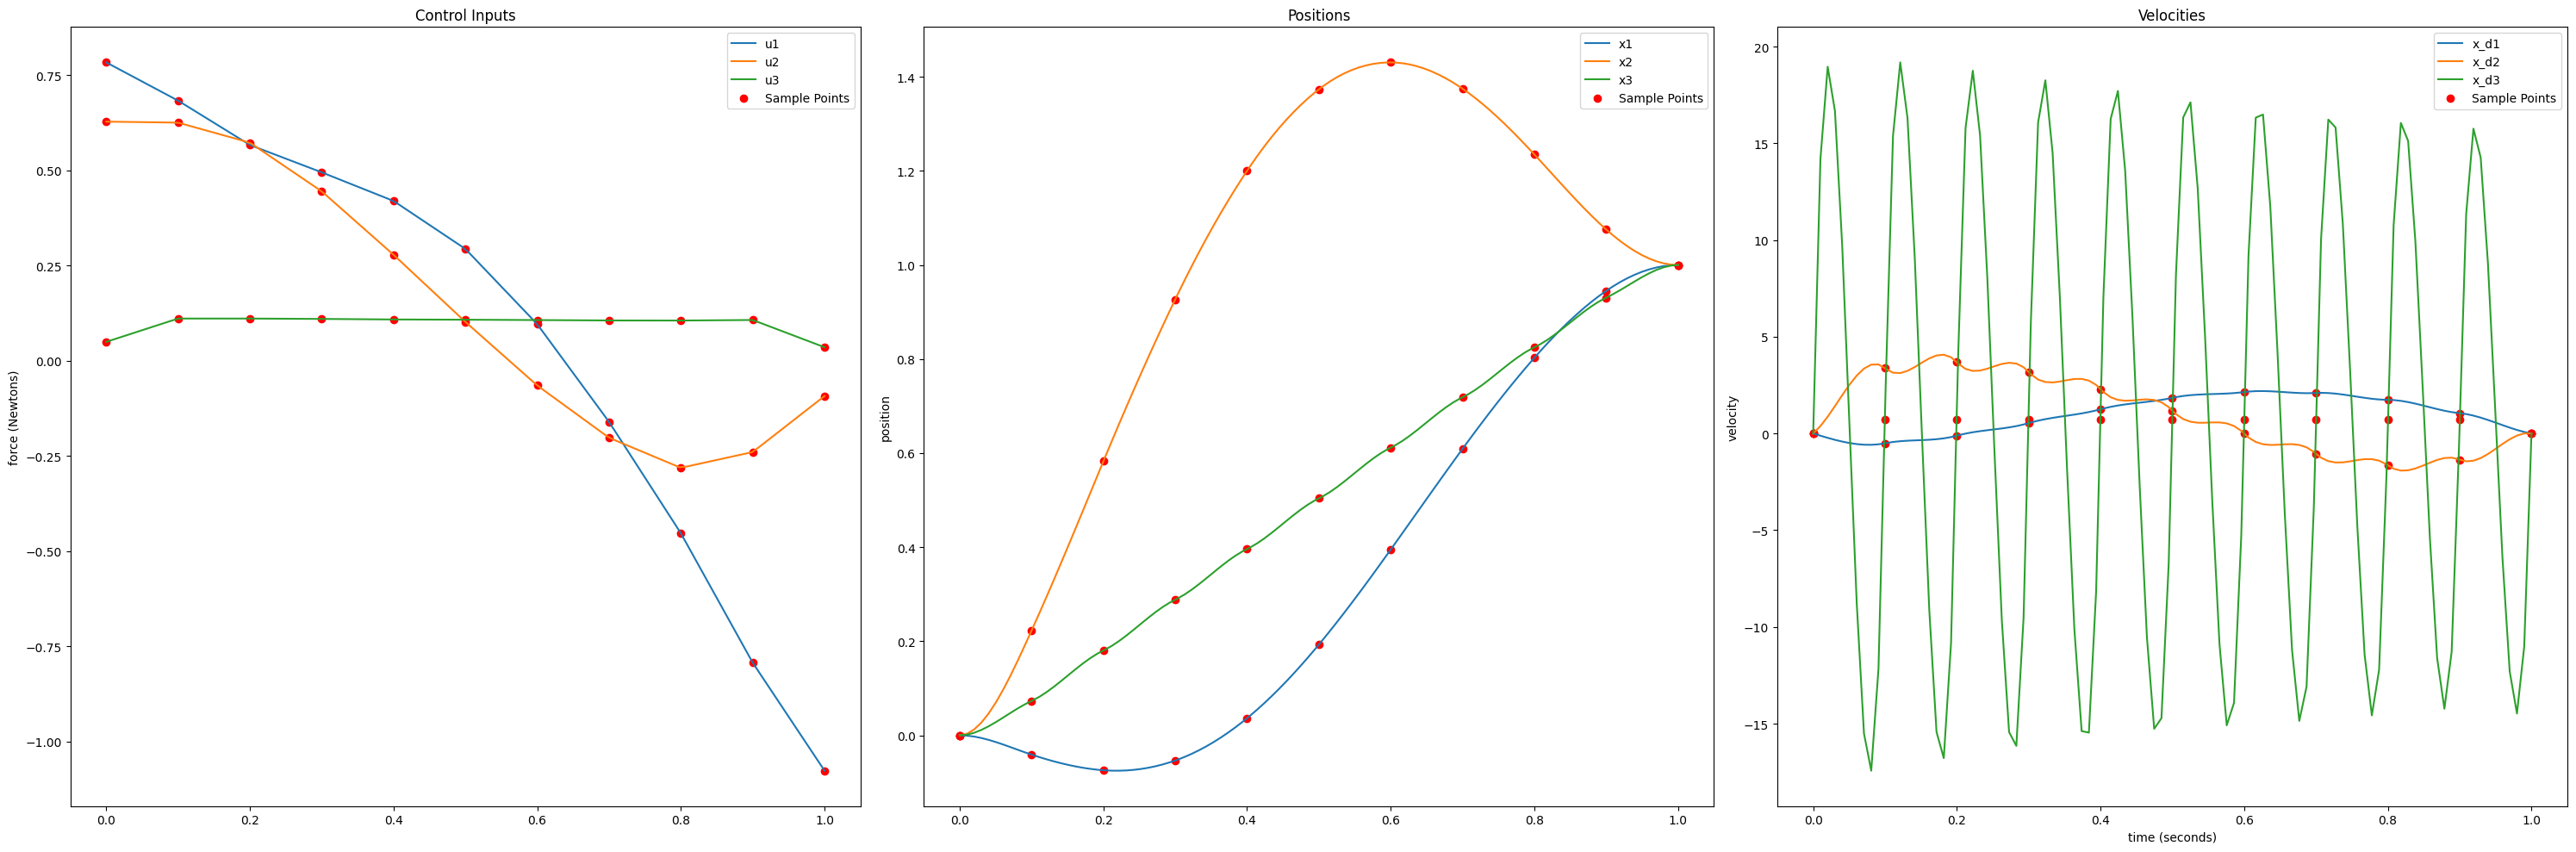

In [57]:
from matplotlib import pyplot as plt
import numpy as np

def breakdown_result(result, num_joints, num_collocation_points):
    # all x + x_dot first
    # all u at the second to last
    # all t at the end (t is the spacing between, so .1, .1, .1, not .1, .2, .3)
    flat = result.get_x_val()
    num_decision_vars = flat.shape[0]
    state = flat[:2*num_joints*num_collocation_points]
    mask = np.arange(len(state)) % 6 < 3
    x = state[mask]
    x_dot = state[~mask]
    u = flat[-NUM_JOINTS*num_collocation_points-num_collocation_points+1:-num_collocation_points+1]
    t = flat[-num_collocation_points+1:]
    return (x, x_dot, u, t)

u_trajectory = direct_collocation.ReconstructInputTrajectory(result)
u_times = np.linspace(u_trajectory.start_time(), u_trajectory.end_time(), 100)
u_values = u_trajectory.vector_values(u_times)

x_trajectory = direct_collocation.ReconstructStateTrajectory(result)
x_times = np.linspace(x_trajectory.start_time(), x_trajectory.end_time(), 100)
x_values = x_trajectory.vector_values(x_times)

x_sampled, x_dot_sampled, u_sampled, t_sampled = breakdown_result(result, NUM_JOINTS, num_samples)

t_absolute = np.cumsum(t_sampled)
t_absolute = np.insert(t_absolute, 0, 0)
t_repeated = np.repeat(t_absolute, NUM_JOINTS)

fig, axs = plt.subplots(1, 3, figsize=(30, 10), sharex=True)

# ---- Control points ----
u_labels = [f"u{i+1}" for i in range(NUM_JOINTS)]
axs[0].plot(times, u_values.T)
axs[0].scatter(t_repeated, u_sampled, color='red', marker='o')
axs[0].set_ylabel("force (Newtons)")
axs[0].set_title("Control Inputs")
axs[0].legend(u_labels + ["Sample Points"])

# ---- Positions ----
pos_labels = [f"x{i+1}" for i in range(NUM_JOINTS)]
axs[1].plot(times, x_values[0:NUM_JOINTS, :].T)
axs[1].scatter(t_repeated, x_sampled, color='red', marker='o')
axs[1].set_ylabel("position")
axs[1].set_title("Positions")
axs[1].legend(pos_labels + ["Sample Points"])

# ---- Velocities ----
vel_labels = [f"x_d{i+1}" for i in range(NUM_JOINTS)]
axs[2].plot(times, x_values[NUM_JOINTS:2*NUM_JOINTS, :].T)
axs[2].scatter(t_repeated, x_dot_sampled, color='red', marker='o')
axs[2].set_ylabel("velocity")
axs[2].set_xlabel("time (seconds)")
axs[2].set_title("Velocities")
axs[2].legend(vel_labels + ["Sample Points"])

plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches="tight")
plt.show()

# # ---- Plot initial guess trajectory (all states) ----
# x_init_values = initial_x_trajectory.vector_values(times)

# plt.figure()
# all_labels = (
#     [f"x{i+1}" for i in range(NUM_JOINTS)] +
#     [f"x_d{i+1}" for i in range(NUM_JOINTS)]
# )
# plt.plot(times, x_init_values[0:2*NUM_JOINTS, :].T, label=all_labels)
# plt.xlabel("time (seconds)")
# plt.legend()
# plt.show()

In [58]:
meshcat.StartRecording(set_visualizations_while_recording=False)

time_step = 1.0 / 99.0
for t in np.append(np.arange(0, x_trajectory.end_time(), time_step), x_trajectory.end_time()):
    context.SetTime(t)
    command = x_trajectory.value(t)
    plant.SetPositions(plant_context_clone, command[:NUM_JOINTS])
    diagram.ForcedPublish(context)

meshcat.StopRecording()
meshcat.PublishRecording()

In [7]:
meshcat.Delete()

In [8]:
import numpy as np
from pydrake.all import (
    DiagramBuilder, AddMultibodyPlantSceneGraph,
    Parser, MeshcatVisualizer, StartMeshcat,
    RigidTransform
)
import xacro

# meshcat = StartMeshcat()

builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)

# Load URDF
urdf = xacro.process_file(
    "models/robot_with_wrist_handle.urdf.xacro"
).toxml()
Parser(plant, scene_graph).AddModelsFromString(urdf, ".urdf")

# ---- Weld base to world (fixed base pose) ----
base = plant.GetBodyByName("base_link")
plant.WeldFrames(
    plant.world_frame(),
    base.body_frame(),
    RigidTransform([0.1, 0.7, 0.0])
)

plant.Finalize()

visualizer_config = VisualizationConfig()
visualizer_config.publish_illustration = True
visualizer_config.publish_inertia = True
ApplyVisualizationConfig(visualizer_config, builder, plant=plant, scene_graph=scene_graph, meshcat=meshcat)

# Add Meshcat
# MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)

diagram = builder.Build()
context = diagram.CreateDefaultContext()
plant_context = plant.GetMyContextFromRoot(context)

# ---- Set ONLY the 4 joint positions (base is welded, so no floating q) ----
q0 = np.array([0.0, 0.5, 3.14])
q0 = np.array([0.0, 0, 0])
plant.SetPositions(plant_context, q0)

diagram.ForcedPublish(context)

print("Loaded with q0 =", q0)

Loaded with q0 = [0. 0. 0.]


In [128]:
import numpy as np

# print(prog.GetAllConstraints())
# print(prog.ToLatex())

builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
parser = Parser(plant, scene_graph)
urdf = xacro.process_file("models/robot_with_wrist_handle.urdf.xacro").toprettyxml(indent='  ')
(robot,) = parser.AddModelsFromString(urdf, ".urdf")   
basebody = plant.GetBodyByName("base_link")
plant.WeldFrames(plant.world_frame(), basebody.body_frame(), RigidTransform([.1,.7,0]))
# plant.set_contact_model(ContactModel.kPoint)
plant.Finalize()

context = plant.CreateDefaultContext()

nq = plant.num_positions()
nv = plant.num_velocities()

q = np.ones(nq)
v = np.ones(nv)

plant.SetPositions(context, q)
plant.SetVelocities(context, v)

M = plant.CalcMassMatrix(context)
bias = plant.CalcBiasTerm(context)
g = plant.CalcGravityGeneralizedForces(context)

print("M =", M)
print("bias =", bias)
print("g =", g)

print(plant.GetJointIndices())
print(plant.GetJointActuatorIndices())


M = [[5.74756239 2.81101568 0.3962444 ]
 [2.81101568 2.20863564 0.60431782]
 [0.3962444  0.60431782 0.33416667]]
bias = [-9.5274866  -0.38682227  2.13759068]
g = [-0. -0. -0.]
[JointIndex(0), JointIndex(1), JointIndex(2), JointIndex(3), JointIndex(4)]
[JointActuatorIndex(0), JointActuatorIndex(1), JointActuatorIndex(2)]
